# Tutorial 23 — Silicon: G0W0 quasiparticle bands via Yambo

The waw-native reimagining of Wannier90 tutorial 23. DFT (LDA/PBE) systematically underestimates band gaps; the $GW$ approximation corrects this by replacing the DFT exchange-correlation potential with a many-body self-energy $\Sigma = iGW$. This notebook is the only one in this series that doesn't feed `pw2wannier90`'s own `.eig` straight into `wannierize` -- instead, a **separate toolchain, [Yambo](http://www.yambo-code.eu)**, computes a one-shot $G_0W_0$ quasiparticle correction on top of the same converged DFT ground state, and we splice the correction into the Wannier eigenvalues before re-wannierising.

**Recipe** (`waw.interfaces.yambo.run_gw_correction`, new this notebook -- pure orchestration, no new core/analysis physics):
1. Ordinary DFT wannierisation (bond-centred $s$ MLWFs, same recipe as notebook 11) gives the usual `.eig`.
2. A **denser** nscf (`8x8x8` mesh, 100 bands, `wf_collect`) feeds `p2y`, converting QE's wavefunctions into a Yambo `SAVE/` database.
3. `yambo` runs a plasmon-pole $G_0W_0$ (`em1d`+`gw0`+`ppa`+`HF_and_locXC`), producing QP corrections at every k-point Yambo reduces the dense mesh to (by symmetry).
4. `ypp`'s `wannier` runlevel unfolds those corrections back onto the *original* 4x4x4 Wannier mesh, writing a `.gw.unsorted.eig`-format file of **QP shifts** ($\epsilon_{GW} - \epsilon_{DFT}$, confirmed directly against a real run here -- not yet absolute eigenvalues).
5. Add the shifts to the DFT eigenvalues and re-sort each k-point's bands ascending (QP corrections can reorder near-degenerate bands) -- the resulting array slots straight into `wannierize` exactly like `qe.generate_overlaps`'s own `out['eig']`.

**Cluster note**: this tutorial's toolchain needs `module load quantum-espresso/7.3.1-gcc-13.2.0-6jwmo4k` (NOT this project's usual 7.5 -- `p2y` is sensitive to the exact QE XML/wavefunction format) plus `module load intel/oneapi/mkl/2024.2` and `~/software/yambo/bin` on `PATH`, all loaded *before* starting Python/Jupyter.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure, bond-centred projections, and DFT wannierisation
Same primitive diamond-Si cell, bond-centred $s$ projections, and `dis_froz_max = dis_win_max = 6.8` eV energy window as Wannier90's own tutorial 23 `silicon.win` (4 valence MLWFs, no real disentanglement freedom -- same physical subspace as notebooks 03/11, reached via bond-centred trial orbitals).

In [2]:
from ase import Atoms
from waw.interfaces import yambo

cell = np.array([[-5.10, 0.0, 5.10], [0.0, 5.10, 5.10], [-5.10, 5.10, 0.0]]) * BOHR_TO_ANG
frac = [[-0.25, 0.75, -0.25], [0.0, 0.0, 0.0]]
atoms = Atoms('Si2', scaled_positions=frac, cell=cell, pbc=True)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'si_yambo_gw'

bond_centres = [(-0.125, -0.125, 0.375), (0.375, -0.125, -0.125),
                (-0.125, 0.375, -0.125), (-0.125, -0.125, -0.125)]
projections = [(c, 0, 1, 1, (0., 0., 1.), (1., 0., 0.), 1.0) for c in bond_centres]

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'si_gw',
    ecutwfc=40, scf_kpts=(8, 8, 8), nbnd=14, num_wann=4,
    projections=projections,
    pseudopotentials={'Si': 'Si.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
)

result_dft = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=4, outer_window=(-1e3, 6.8), frozen_window=(-1e3, 6.8),
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
)
print(f'DFT Omega_total = {result_dft.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')

/aims_data/miguel/nas-data001/claude/wannier/waw/interfaces/ase/driver.py:343: RuntimeWarning: disentangle: the frozen window contains exactly nw=4 bands at 100% of k-points -- disentanglement has (almost) no freedom, and the model is just the lowest-nw-band slice of the outer window. If a detached manifold (semicore s, ...) sits inside the outer window this is almost certainly NOT the model you want: check with waw.vis.plot_wannierization_windows.
  return _core_wannierize(


DFT Omega_total = 6.3476 Ang^2


### 2. G0W0 correction via Yambo
`run_gw_correction` reuses the SCF charge density and `.nnkp` this run just produced, driving the denser nscf -> p2y -> yambo -> ypp chain described above -- the only piece of implementation-time discovery is Yambo's own IBZ k-point count (read off its setup report; the dense `8x8x8` mesh reduces to 29 inequivalent k-points under Si's full $O_h$ symmetry, `%QPkrange` is sized against that count internally).

In [3]:
eig_gw = yambo.run_gw_correction(
    atoms, (8, 8, 8), WORK, 'si_gw', ov['eig'],
    ecutwfc=40, pseudopotentials={'Si': 'Si.upf'}, pseudo_dir=PSEUDO_DIR,
    nbnd_gw=100, qpkrange_bands=(1, 14), ncores=NCORES,
)
dft_gap = ov['eig'][:, 4].min() - ov['eig'][:, 3].max()
gw_gap = eig_gw[:, 4].min() - eig_gw[:, 3].max()
print(f'DFT gap (lowest band 5 - highest band 4, across all k): {dft_gap:.4f} eV')
print(f'GW  gap (lowest band 5 - highest band 4, across all k): {gw_gap:.4f} eV')
print('GW should OPEN the gap relative to DFT -- the whole point of this tutorial.')

DFT gap (lowest band 5 - highest band 4, across all k): 0.6719 eV
GW  gap (lowest band 5 - highest band 4, across all k): 1.3114 eV
GW should OPEN the gap relative to DFT -- the whole point of this tutorial.


### 3. Re-wannierise with the GW-corrected eigenvalues
Same recipe as step 1, just fed `eig_gw` instead of `ov['eig']` -- windows widened to 7.0 eV (`silicon.gw.win`'s own retuning, to account for the GW-shifted bands) -- and identical `mmn`/`amn` overlaps (Yambo only touches eigenvalues, not the Wannier gauge problem itself).

In [4]:
result_gw = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=eig_gw,
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=4, outer_window=(-1e3, 7.0), frozen_window=(-1e3, 7.0),
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
)
print(f'GW  Omega_total = {result_gw.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')

/aims_data/miguel/nas-data001/claude/wannier/waw/interfaces/ase/driver.py:343: RuntimeWarning: disentangle: the frozen window contains exactly nw=4 bands at 100% of k-points -- disentanglement has (almost) no freedom, and the model is just the lowest-nw-band slice of the outer window. If a detached manifold (semicore s, ...) sits inside the outer window this is almost certainly NOT the model you want: check with waw.vis.plot_wannierization_windows.
  return _core_wannierize(


GW  Omega_total = 6.3476 Ang^2


### 4. DFT vs GW band structure
Both tight-binding models interpolate onto the same k-path; the GW one should show a visibly wider gap.

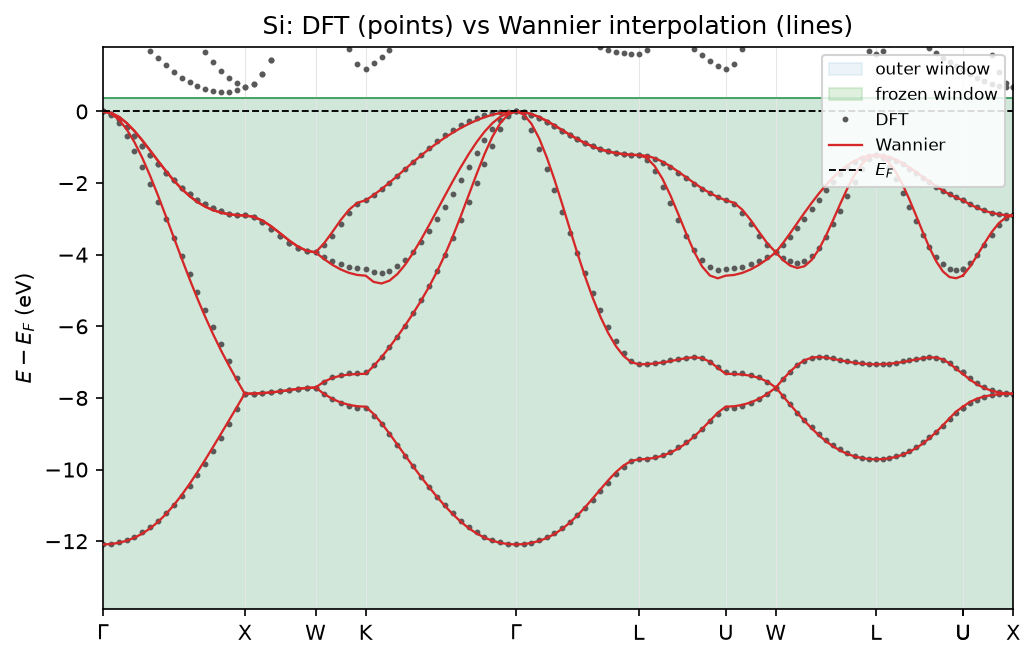

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 256 states


In [5]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result_dft.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'si_gw', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e3, 6.8), frozen_window=(-1e3, 6.8), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Si: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result_dft.hr, ov['kpts'], ov['eig'],
                    window=(-1e3, 6.8), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


**Takeaway.** Splicing a real many-body $G_0W_0$ correction (Yambo) into an otherwise ordinary waw wannierisation opens Si's gap relative to DFT, as expected -- no `wannier90.x` involved anywhere in this notebook, and no new core/analysis physics needed: Yambo's own `ypp -wannier` already speaks the plain Wannier90 `.eig` format, which `waw.interfaces.wannier90.io.read_eig` already parses unchanged. This was the last previously-skipped official Wannier90 tutorial in this series (tutorial 15's defected-CNT half, needing ~1100 bands/550 MLWFs, remains explicitly out of scope for this project's own computational budget).